# Planck FFP10 noise maps — visualization & noise power spectra

This notebook loads the **Planck Full Focal Plane 10 (FFP10)** end-to-end **noise realizations**
downloaded from the [Planck Legacy Archive (PLA)](https://pla.esac.esa.int/), visualizes them on
the sky, and computes **noise angular power spectra** $N_\ell$.

## What are these maps?

FFP10 noise maps are **Monte Carlo realizations of instrumental noise** for Planck HFI
frequency channels. They are generated from the full mission timeline processing pipeline and
include realistic:

- detector white noise and $1/f$ components as realized in map-making,
- scanning strategy / hit-count anisotropy (noise is **not** uniform on the sky),
- polarization for the CMB channels (100–353 GHz).

They are the standard noise products used when coadding signal simulations (CMB, tSZ, CIB, …)
to build realistic multi-frequency skies for ILC, component separation, and power-spectrum
validation — the natural next step after `coadd_multifrequency_sky_maps.ipynb` /
`hilc_y_map_pyilc.ipynb`.

## Local data

```
/home/ext_andyxlcnb_gmail_com/cosmology_data/planck_noise/
```

| Frequency | Stokes | Units | Realizations on disk |
|-----------|--------|-------|----------------------|
| 100, 143, 217, 353 GHz | $I,Q,U$ | $\mathrm{K}_\mathrm{CMB}$ | `mc_00000`, `mc_00001` |
| 545, 857 GHz | $I$ only | $\mathrm{MJy\,sr^{-1}}$ | `mc_00000`, `mc_00001` |

Naming:

```text
ffp10_noise_{freq}_full_map_mc_{XXXXX}.fits
```

- **`full`**: full-mission map-making (vs half-mission `hm1`/`hm2` or odd/even rings `oe1`/`oe2`).
- **`mc_XXXXX`**: noise realization index ($00000$–$00299$ available at PLA).

Native HEALPix resolution: **$N_\mathrm{side}=2048$** (RING ordering).

## Notebook plan

1. Configure paths and plotting resolution (`USE_DOWNGRADE`).
2. Load helpers + inventory of available files.
3. **Map gallery** — Mollweide views of $T$ (and $Q,U$ for pol channels).
4. **Pixel statistics** — mean, RMS, histogram; independence of two MCs.
5. **Noise power spectra** $N_\ell^{TT}$ (and $EE$, $BB$ where available).
6. **Realization comparison** — auto-spectra of two MCs should match; their **cross** should be $\approx 0$.
7. Multi-frequency $N_\ell$ overview and effective white-noise level.

> **Kernel**: use `cosmo_env` (`/home/ext_andyxlcnb_gmail_com/envs/cosmo_env`) with `healpy`, `astropy`, `numpy`, `matplotlib`.


In [1]:
from __future__ import annotations

from pathlib import Path

import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

# ---------------------------------------------------------------------------
# Paths & analysis controls
# ---------------------------------------------------------------------------
NOISE_DIR = Path("/home/ext_andyxlcnb_gmail_com/cosmology_data/planck_noise")
FIG_DIR = Path("/home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Frequencies present on disk (HFI)
FREQS_POL = (100, 143, 217, 353)   # IQU in K_CMB
FREQS_INT = (545, 857)             # I only in MJy/sr
FREQS_ALL = FREQS_POL + FREQS_INT

REALIZATIONS = (0, 1)              # mc_00000, mc_00001
SPLIT = "full"                     # full-mission; alternatives: hm1, hm2, oe1, oe2

# Resolution for visualization / spectra
# Native FFP10 maps are Nside=2048 (~50M pixels). Downgrade for interactive work.
USE_DOWNGRADE = True
NSIDE_PLOT = 256                   # used when USE_DOWNGRADE=True
LMAX_SPEC = 1500                   # requested anafast band limit (auto-capped by Nside)
ANAFAST_ITER = 1                   # 0 is faster; 3 is more accurate for masked maps
DELTA_ELL = 20                     # multipole bin width for display

# Which frequency is used for the detailed single-channel walkthrough
FOCUS_FREQ = 143
FOCUS_REAL = 0

assert NOISE_DIR.is_dir(), f"Missing noise directory: {NOISE_DIR}"
print(f"Noise directory: {NOISE_DIR}")
print(f"Files: {len(list(NOISE_DIR.glob('*.fits')))}")
print(f"USE_DOWNGRADE={USE_DOWNGRADE} -> plot Nside={NSIDE_PLOT if USE_DOWNGRADE else 2048}")
print(f"LMAX_SPEC={LMAX_SPEC}, DELTA_ELL={DELTA_ELL}")


Noise directory: /home/ext_andyxlcnb_gmail_com/cosmology_data/planck_noise
Files: 12
USE_DOWNGRADE=True -> plot Nside=256
LMAX_SPEC=1500, DELTA_ELL=20


## 1. File naming helpers and map I/O

Planck FFP10 simulated maps are standard HEALPix binary tables. Polarization channels
store three columns (`I_STOKES`, `Q_STOKES`, `U_STOKES`); sub-mm intensity channels store
a single `I` column.

`healpy.read_map(..., field=None)` returns:

- shape `(3, Npix)` for IQU maps,
- shape `(Npix,)` for intensity-only maps.


In [2]:
def noise_filename(freq_ghz: int, realization: int = 0, split: str = SPLIT) -> str:
    'Return FFP10 noise FITS basename for a given frequency and MC index.'
    return f"ffp10_noise_{freq_ghz}_{split}_map_mc_{realization:05d}.fits"


def noise_path(freq_ghz: int, realization: int = 0, split: str = SPLIT) -> Path:
    return NOISE_DIR / noise_filename(freq_ghz, realization, split)


def is_polarized_channel(freq_ghz: int) -> bool:
    return freq_ghz in FREQS_POL


def map_units(freq_ghz: int) -> str:
    return r"K$_\mathrm{CMB}$" if is_polarized_channel(freq_ghz) else r"MJy sr$^{-1}$"


def load_noise_map(
    freq_ghz: int,
    realization: int = 0,
    *,
    field: int | tuple | None = None,
    nside_out: int | None = None,
    split: str = SPLIT,
) -> np.ndarray:
    '''
    Load an FFP10 noise map.

    Parameters
    ----------
    field
        Stokes component(s). None -> all available fields.
        For pol channels, 0/1/2 = I/Q/U. For intensity-only, only 0 is valid.
    nside_out
        If set, ud_grade the map to this Nside (useful for quick plots).
    '''
    path = noise_path(freq_ghz, realization, split)
    if not path.is_file():
        raise FileNotFoundError(path)

    m = hp.read_map(str(path), field=field, dtype=np.float64, nest=False)

    # healpy returns a list when multiple fields are requested
    if isinstance(m, list):
        m = np.asarray(m)

    if nside_out is not None:
        if m.ndim == 1:
            m = hp.ud_grade(m, nside_out)
        else:
            m = np.asarray([hp.ud_grade(comp, nside_out) for comp in m])
    return m


def summarize_map(m: np.ndarray, label: str = "") -> None:
    'Print basic pixel statistics (works for 1D maps or IQU stacks).'
    m = np.asarray(m)
    if m.ndim > 1:
        for i, name in enumerate(["I", "Q", "U"][: m.shape[0]]):
            summarize_map(m[i], f"{label} [{name}]" if label else name)
        return
    finite = np.isfinite(m)
    x = m[finite]
    print(
        f"{label:28s}  Npix={x.size:9d}  mean={x.mean():+.4e}  "
        f"std={x.std():.4e}  min={x.min():+.4e}  max={x.max():+.4e}"
    )


# Inventory
print("Available noise maps:\n")
print(f"{'file':<48} {'size_MB':>8}  fields / units")
print("-" * 80)
for freq in FREQS_ALL:
    for real in REALIZATIONS:
        p = noise_path(freq, real)
        if not p.is_file():
            print(f"{p.name:<48}  MISSING")
            continue
        with fits.open(p) as hdul:
            hdr = hdul[1].header
            nside = hdr.get("NSIDE", "?")
            ttypes = [hdr.get(f"TTYPE{i}", "") for i in range(1, hdr.get("TFIELDS", 0) + 1)]
            tunit = hdr.get("TUNIT1", "?")
        print(
            f"{p.name:<48} {p.stat().st_size / 1e6:8.1f}  "
            f"Nside={nside}  {ttypes}  [{tunit}]"
        )


Available noise maps:

file                                              size_MB  fields / units
--------------------------------------------------------------------------------
ffp10_noise_100_full_map_mc_00000.fits              604.0  Nside=2048  ['I_STOKES', 'Q_STOKES', 'U_STOKES']  [K_CMB]
ffp10_noise_100_full_map_mc_00001.fits              604.0  Nside=2048  ['I_STOKES', 'Q_STOKES', 'U_STOKES']  [K_CMB]
ffp10_noise_143_full_map_mc_00000.fits              604.0  Nside=2048  ['I_STOKES', 'Q_STOKES', 'U_STOKES']  [K_CMB]
ffp10_noise_143_full_map_mc_00001.fits              604.0  Nside=2048  ['I_STOKES', 'Q_STOKES', 'U_STOKES']  [K_CMB]
ffp10_noise_217_full_map_mc_00000.fits              604.0  Nside=2048  ['I_STOKES', 'Q_STOKES', 'U_STOKES']  [K_CMB]
ffp10_noise_217_full_map_mc_00001.fits              604.0  Nside=2048  ['I_STOKES', 'Q_STOKES', 'U_STOKES']  [K_CMB]
ffp10_noise_353_full_map_mc_00000.fits              604.0  Nside=2048  ['I_STOKES', 'Q_STOKES', 'U_STOKES']  [K_CMB]
ffp

## 2. Visualize a single noise realization

Instrumental noise maps look **structurally different** from cosmological signal:

- **Near-zero mean**, Gaussian-like pixel histogram.
- **Scanning stripes** and deeper coverage near the ecliptic poles (lower noise) — a
  fingerprint of the Planck scanning strategy.
- Polarization noise ($Q,U$) is typically **noisier** than $I$ at the same channel
  (fewer effective samples per Stokes parameter).

We plot at `NSIDE_PLOT` when `USE_DOWNGRADE=True` for a fast interactive preview.
For publication figures set `USE_DOWNGRADE=False` (native $N_\mathrm{side}=2048$).


Loading 143 GHz, realization 0 at Nside=256 ...


143 GHz mc=00000 [I]          Npix=   786432  mean=+7.3264e-08  std=2.5536e-06  min=-1.3186e-05  max=+1.3609e-05
143 GHz mc=00000 [Q]          Npix=   786432  mean=-9.5935e-08  std=5.0920e-06  min=-2.8426e-05  max=+2.7914e-05
143 GHz mc=00000 [U]          Npix=   786432  mean=-2.1586e-08  std=5.1721e-06  min=-3.1570e-05  max=+3.6445e-05


/tmp/ipykernel_140226/2497216590.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved /home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures/planck_noise_143ghz_mc00000_mollview.png


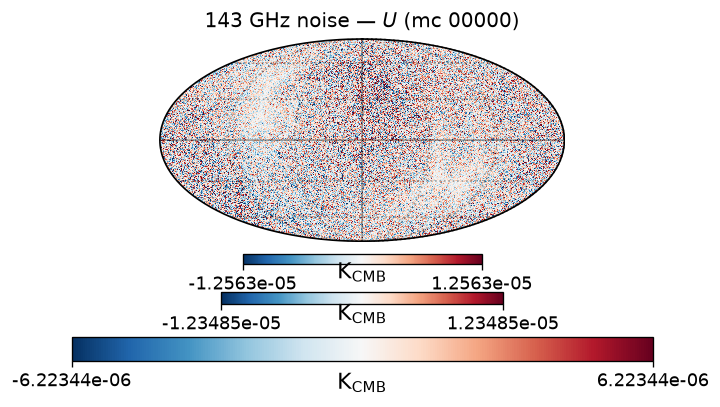

In [3]:
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
})


def plot_nside() -> int:
    return NSIDE_PLOT if USE_DOWNGRADE else 2048


def symmetric_vmax(m: np.ndarray, pct: tuple[float, float] = (1, 99)) -> float:
    "Symmetric colour limit from percentiles (noise is +/-)."
    x = np.asarray(m, dtype=np.float64)
    x = x[np.isfinite(x)]
    lo, hi = np.percentile(x, pct)
    return float(max(abs(lo), abs(hi)))


def mollview_noise(
    m: np.ndarray,
    title: str,
    unit: str,
    *,
    sub=None,
    fig=None,
    cmap: str = "RdBu_r",
    pct: tuple[float, float] = (1, 99),
    nest: bool = False,
) -> None:
    """
    Mollweide plot with symmetric percentile colour limits.

    Notes on multi-panel use
    ------------------------
    healpy.mollview does **not** play well with plt.tight_layout(): the latter
    collapses subplots so only the last map + a stack of colourbars survives.
    Pass an explicit ``fig`` and ``sub=(nrows, ncols, index)``, and never call
    tight_layout on that figure. Prefer fig.savefig(..., bbox_inches="tight").
    """
    x = np.asarray(m, dtype=np.float64)
    vmax = symmetric_vmax(x, pct)
    kw = dict(
        title=title,
        unit=unit,
        min=-vmax,
        max=vmax,
        cmap=cmap,
        nest=nest,
        notext=False,
        xsize=800,
    )
    if sub is not None:
        kw["sub"] = sub
    if fig is not None:
        kw["fig"] = fig
    hp.mollview(x, **kw)
    hp.graticule(dpar=30, dmer=60, alpha=0.35)


# --- Focus channel: temperature + polarization if available ---
nside_vis = plot_nside()
print(f"Loading {FOCUS_FREQ} GHz, realization {FOCUS_REAL} at Nside={nside_vis} ...")
focus = load_noise_map(FOCUS_FREQ, FOCUS_REAL, nside_out=nside_vis)
summarize_map(focus, f"{FOCUS_FREQ} GHz mc={FOCUS_REAL:05d}")

unit = map_units(FOCUS_FREQ)
if is_polarized_channel(FOCUS_FREQ):
    fig = plt.figure(figsize=(13.0, 4.0))
    for i, stokes in enumerate(["I", "Q", "U"]):
        mollview_noise(
            focus[i],
            title=rf"{FOCUS_FREQ} GHz noise — ${stokes}$ (mc {FOCUS_REAL:05d})",
            unit=unit,
            sub=(1, 3, i + 1),
            fig=fig,
        )
else:
    fig = plt.figure(figsize=(7.5, 4.5))
    mollview_noise(
        focus,
        title=rf"{FOCUS_FREQ} GHz noise — $I$ (mc {FOCUS_REAL:05d})",
        unit=unit,
        fig=fig,
    )

# Do NOT call tight_layout() with healpy mollview multi-panels.
out = FIG_DIR / f"planck_noise_{FOCUS_FREQ}ghz_mc{FOCUS_REAL:05d}_mollview.png"
fig.savefig(out, bbox_inches="tight", pad_inches=0.15)
print("Saved", out)
plt.show()


## 3. Multi-frequency noise gallery (temperature)

Noise RMS grows toward higher HFI frequencies (especially 545/857 GHz), but **units
differ**: 100–353 GHz are in thermodynamic $\mathrm{K}_\mathrm{CMB}$, while 545/857 GHz
are in $\mathrm{MJy\,sr^{-1}}$. Do **not** compare those colour bars quantitatively without
a unit conversion.

Below we show one realization of $I$ for every available frequency.


100 GHz I (mc00000)           Npix=   786432  mean=+1.4828e-07  std=4.6046e-06  min=-2.9275e-05  max=+2.6139e-05


143 GHz I (mc00000)           Npix=   786432  mean=+7.3264e-08  std=2.5536e-06  min=-1.3186e-05  max=+1.3609e-05


217 GHz I (mc00000)           Npix=   786432  mean=+1.7162e-07  std=3.8881e-06  min=-2.2752e-05  max=+5.2506e-05


353 GHz I (mc00000)           Npix=   786432  mean=+2.2240e-07  std=1.3264e-05  min=-1.1996e-04  max=+7.8696e-05


545 GHz I (mc00000)           Npix=   786432  mean=-7.8466e-03  std=4.8533e-02  min=-1.9015e+00  max=+1.7870e+00


857 GHz I (mc00000)           Npix=   786432  mean=-4.7237e-03  std=2.2379e-02  min=-2.5081e+00  max=+4.9670e-01


/tmp/ipykernel_140226/4145088088.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved /home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures/planck_noise_allfreq_I_gallery.png


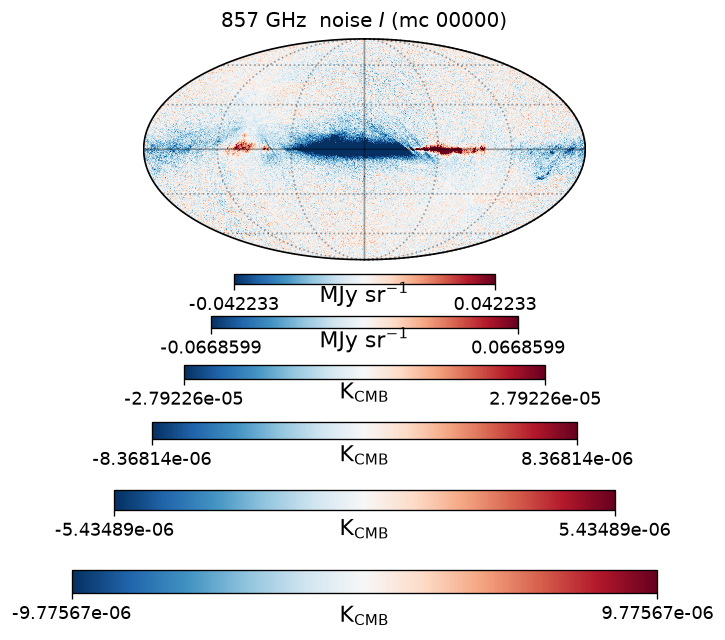

In [4]:
nside_vis = plot_nside()
n_freq = len(FREQS_ALL)
ncols = 3
nrows = int(np.ceil(n_freq / ncols))

# Explicit figure handle + sub= index is the reliable multi-panel pattern.
# Never use plt.tight_layout() here — it destroys healpy's subplot geometry
# (classic symptom: only the last map remains, with a stack of colourbars).
fig = plt.figure(figsize=(4.6 * ncols, 3.6 * nrows))
for i, freq in enumerate(FREQS_ALL):
    m = load_noise_map(freq, realization=0, field=0, nside_out=nside_vis)
    summarize_map(m, f"{freq} GHz I (mc00000)")
    mollview_noise(
        m,
        title=rf"{freq} GHz  noise $I$ (mc 00000)",
        unit=map_units(freq),
        sub=(nrows, ncols, i + 1),
        fig=fig,
        pct=(2, 98),
    )

out = FIG_DIR / "planck_noise_allfreq_I_gallery.png"
fig.savefig(out, bbox_inches="tight", pad_inches=0.2)
print("Saved", out)
plt.show()


## 4. Pixel histograms

For a pure noise realization the 1-point PDF is close to Gaussian, but **heteroscedastic**:
pixel variance varies across the sky (hit counts). That broadens the histogram slightly
relative to a single $\mathcal{N}(0,\sigma^2)$.

We compare the two Monte Carlo realizations at the focus frequency — they should have
nearly identical RMS. Their difference should have RMS $\approx \sqrt{2}\,\sigma$ if the
realizations are independent and identically distributed.


Saved /home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures/planck_noise_143ghz_histograms.png


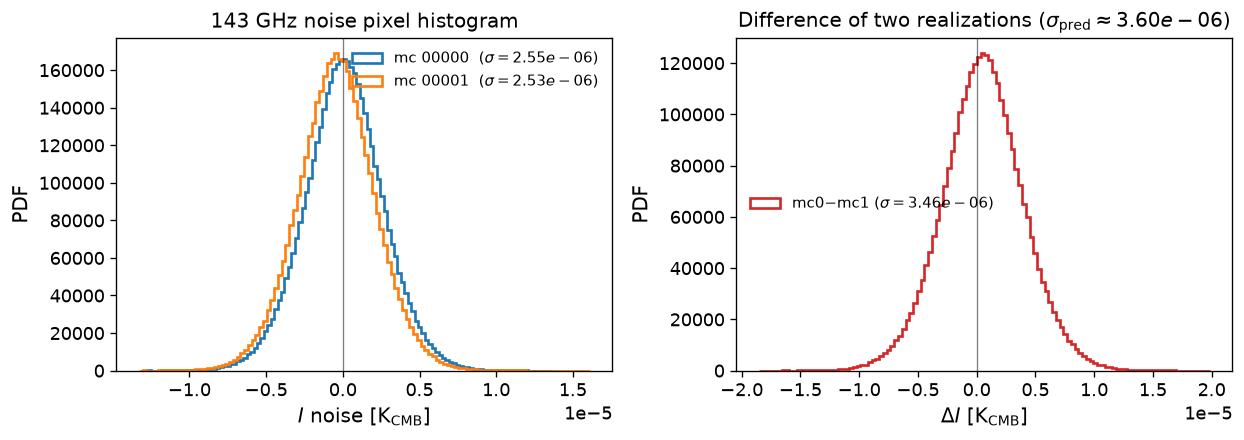


RMS ratio sigma(diff)/sigma(mc0) = 1.354  (expect ~1.414 for independent realizations)


In [5]:
nside_vis = plot_nside()
maps_I = {
    real: load_noise_map(FOCUS_FREQ, real, field=0, nside_out=nside_vis)
    for real in REALIZATIONS
}
diff = maps_I[0] - maps_I[1]
sigma_pred = np.sqrt(maps_I[0].std() ** 2 + maps_I[1].std() ** 2)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

ax = axes[0]
for real, m in maps_I.items():
    ax.hist(
        m, bins=120, density=True, histtype="step", lw=1.6,
        label=rf"mc {real:05d}  ($\sigma={m.std():.2e}$)",
    )
ax.set_xlabel(rf"$I$ noise [{map_units(FOCUS_FREQ)}]")
ax.set_ylabel("PDF")
ax.set_title(rf"{FOCUS_FREQ} GHz noise pixel histogram")
ax.legend(frameon=False, fontsize=9)
ax.axvline(0.0, color="k", lw=0.8, alpha=0.5)

ax = axes[1]
ax.hist(
    diff, bins=120, density=True, histtype="step", lw=1.6, color="C3",
    label=rf"mc0$-$mc1 ($\sigma={diff.std():.2e}$)",
)
ax.axvline(0.0, color="k", lw=0.8, alpha=0.5)
ax.set_xlabel(rf"$\Delta I$ [{map_units(FOCUS_FREQ)}]")
ax.set_ylabel("PDF")
ax.set_title(
    rf"Difference of two realizations "
    rf"($\sigma_{{\rm pred}}\approx{sigma_pred:.2e}$)"
)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
out = FIG_DIR / f"planck_noise_{FOCUS_FREQ}ghz_histograms.png"
fig.savefig(out, bbox_inches="tight")
print("Saved", out)
plt.show()

print(
    f"\nRMS ratio sigma(diff)/sigma(mc0) = {diff.std() / maps_I[0].std():.3f}  "
    f"(expect ~{np.sqrt(2):.3f} for independent realizations)"
)


## 5. Noise power spectra $N_\ell$

### Definition

For a full-sky map $n(\hat{n})$ with spherical harmonic coefficients $n_{\ell m}$,

$$
N_\ell
=
\frac{1}{2\ell+1}
\sum_{m=-\ell}^{\ell}
\big|n_{\ell m}\big|^2
=
\langle n_{\ell m}\, n_{\ell m}^{*}\rangle_{m}.
$$

Estimated with `healpy.anafast` after subtracting the map mean. We optionally divide by
the **HEALPix pixel window** $w_\ell^2$ so that $N_\ell$ is referred to a continuous field
rather than the pixelized one:

$$
N_\ell^{\mathrm{pix\text{-}deconv}}
=
\frac{N_\ell^{\mathrm{raw}}}{w_\ell^{2}}.
$$

### What to expect

- Planck noise spectra are **approximately white** over a wide multipole range, with
  excess power at low $\ell$ from residual $1/f$ / map-making modes and a fall-off near
  the beam / pixel scale.
- **$N_\ell^{EE}$ and $N_\ell^{BB}$** (pol channels) are typically higher than $N_\ell^{TT}$.
- Two independent realizations have **similar auto-spectra** and a **near-zero cross-spectrum**:

$$
N_\ell^{0\times 1}
=
\frac{1}{2\ell+1}\sum_m n_{\ell m}^{(0)}\,n_{\ell m}^{(1)*}
\;\approx\; 0.
$$

That cross-check is a standard null test that the MCs are uncorrelated.


In [6]:
def max_lmax_for_nside(nside: int) -> int:
    "Safe multipole limit for HEALPix maps (~3*Nside-1)."
    return 3 * int(nside) - 1


def pixel_window(nside: int, lmax: int) -> np.ndarray:
    """
    HEALPix temperature pixel window w_ell of length lmax+1.

    healpy.pixwin only returns multipoles up to ~4*Nside; pad with the last
    value if a larger lmax was requested.
    """
    wl = np.asarray(hp.pixwin(nside, lmax=None, pol=False), dtype=np.float64)
    if wl.size >= lmax + 1:
        return wl[: lmax + 1]
    pad = np.full(lmax + 1 - wl.size, wl[-1] if wl.size else 1.0)
    return np.concatenate([wl, pad])


def compute_cl(
    map_a: np.ndarray,
    map_b: np.ndarray | None = None,
    *,
    lmax: int | None = None,
    iter: int = ANAFAST_ITER,
    deconv_pixel_window: bool = True,
) -> np.ndarray:
    """
    Auto- or cross-spectrum with mean subtraction and optional pixel-window deconvolution.
    Maps must share the same Nside. lmax defaults to min(LMAX_SPEC, 3*Nside-1).
    """
    a = np.asarray(map_a, dtype=np.float64)
    a = a - np.mean(a[np.isfinite(a)])
    nside = hp.get_nside(a)
    if lmax is None:
        lmax = min(LMAX_SPEC, max_lmax_for_nside(nside))

    if map_b is None:
        cl = hp.anafast(a, lmax=lmax, iter=iter)
    else:
        b = np.asarray(map_b, dtype=np.float64)
        b = b - np.mean(b[np.isfinite(b)])
        cl = hp.anafast(a, b, lmax=lmax, iter=iter)

    if deconv_pixel_window:
        wl = pixel_window(nside, lmax)
        good = wl > 1e-6
        cl_out = np.zeros_like(cl)
        cl_out[good] = cl[good] / wl[good] ** 2
        cl = cl_out
    return cl


def compute_pol_cls(
    iqu: np.ndarray,
    *,
    lmax: int | None = None,
    iter: int = ANAFAST_ITER,
    deconv_pixel_window: bool = True,
) -> dict[str, np.ndarray]:
    """
    Full polarization anafast for an (I,Q,U) map stack.

    Returns TT, EE, BB, TE (and EB/TB, unused below).
    """
    assert iqu.shape[0] == 3, "expected (3, Npix) IQU map"
    maps = [comp - np.mean(comp[np.isfinite(comp)]) for comp in iqu]
    nside = hp.get_nside(maps[0])
    if lmax is None:
        lmax = min(LMAX_SPEC, max_lmax_for_nside(nside))

    # healpy returns [TT, EE, BB, TE, EB, TB]
    cls = hp.anafast(maps, lmax=lmax, iter=iter)
    names = ["TT", "EE", "BB", "TE", "EB", "TB"]
    out = {n: np.asarray(c, dtype=np.float64) for n, c in zip(names, cls)}
    if deconv_pixel_window:
        wl = pixel_window(nside, lmax)
        good = wl > 1e-6
        for k in out:
            cl_out = np.zeros_like(out[k])
            cl_out[good] = out[k][good] / wl[good] ** 2
            out[k] = cl_out
    return out


def bin_cl(cl: np.ndarray, delta_ell: int = DELTA_ELL) -> tuple[np.ndarray, np.ndarray]:
    "Simple top-hat binning in multipole (skips monopole/dipole)."
    ell = np.arange(cl.size)
    n_bins = max(cl.size // delta_ell, 1)
    ell_b, cl_b = [], []
    for i in range(n_bins):
        lo = i * delta_ell
        hi = min((i + 1) * delta_ell, cl.size)
        if hi <= 2:
            continue
        sel = slice(max(lo, 2), hi)
        w = 2 * ell[sel] + 1  # mode-count weights
        if w.sum() == 0:
            continue
        ell_b.append(np.average(ell[sel], weights=w))
        cl_b.append(np.average(cl[sel], weights=w))
    return np.asarray(ell_b), np.asarray(cl_b)


def dl_from_cl(ell: np.ndarray, cl: np.ndarray) -> np.ndarray:
    "D_ell = ell(ell+1) C_ell / (2pi)."
    return ell * (ell + 1.0) * cl / (2.0 * np.pi)


# Spectra on downgraded maps are fine for shape checks;
# for quantitative high-ell noise use USE_DOWNGRADE=False and raise LMAX_SPEC.
nside_spec = plot_nside()
LMAX_EFF = min(LMAX_SPEC, max_lmax_for_nside(nside_spec))
print(f"Power spectra at Nside={nside_spec}, lmax={LMAX_EFF} (requested {LMAX_SPEC})")


Power spectra at Nside=256, lmax=767 (requested 1500)


### 5.1 Focus frequency: $TT$ auto-spectra of both realizations + cross

If the two MCs are independent draws from the same noise distribution:

| Spectrum | Expectation |
|----------|-------------|
| $N_\ell^{00}$, $N_\ell^{11}$ | same mean noise bias |
| $N_\ell^{0\times 1}$ | $\approx 0$ (scatter about zero) |


Loading 143 GHz realizations for spectra (Nside=256)...


Saved /home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures/planck_noise_143ghz_Nell_auto_cross.png


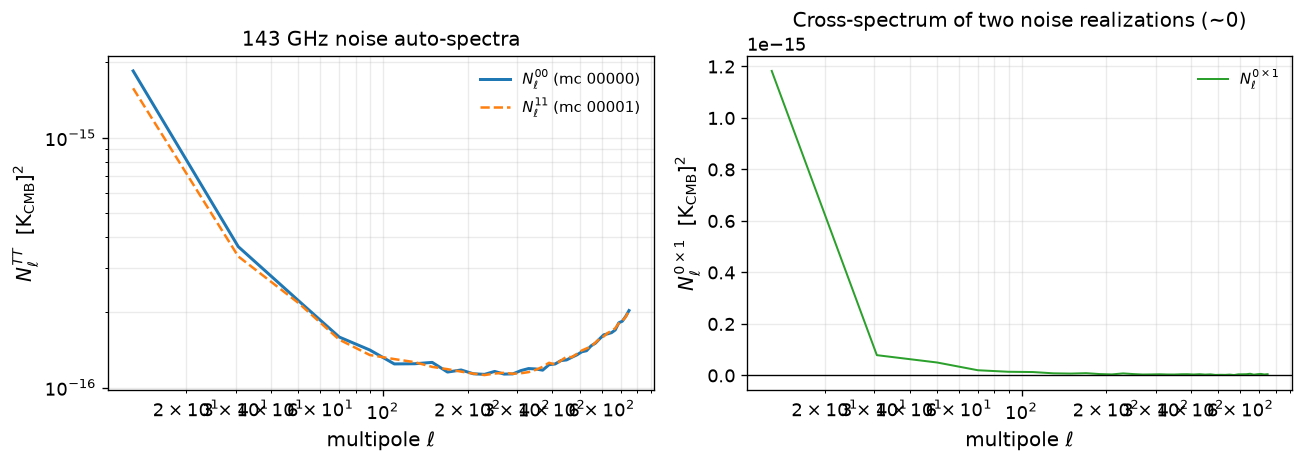

Mean N_ell over 50<=ell<=500:  auto0=1.2532e-16, auto1=1.2519e-16, cross=6.6849e-18  (|cross|/auto0=5.334e-02)


In [7]:
print(f"Loading {FOCUS_FREQ} GHz realizations for spectra (Nside={nside_spec})...")
I0 = load_noise_map(FOCUS_FREQ, 0, field=0, nside_out=nside_spec)
I1 = load_noise_map(FOCUS_FREQ, 1, field=0, nside_out=nside_spec)

cl_00 = compute_cl(I0)
cl_11 = compute_cl(I1)
cl_01 = compute_cl(I0, I1)
ell = np.arange(cl_00.size)  # matches effective lmax used by compute_cl

ell_b, cl00_b = bin_cl(cl_00)
_, cl11_b = bin_cl(cl_11)
_, cl01_b = bin_cl(cl_01)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

ax = axes[0]
ax.loglog(ell_b, cl00_b, lw=1.8, label=r"$N_\ell^{00}$ (mc 00000)")
ax.loglog(ell_b, cl11_b, lw=1.5, ls="--", label=r"$N_\ell^{11}$ (mc 00001)")
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(rf"$N_\ell^{{TT}}$  [{map_units(FOCUS_FREQ)}$]^2$")
ax.set_title(rf"{FOCUS_FREQ} GHz noise auto-spectra")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", alpha=0.25)

ax = axes[1]
ax.plot(ell_b, cl01_b, lw=1.2, color="C2", label=r"$N_\ell^{0\times 1}$")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(rf"$N_\ell^{{0\times 1}}$  [{map_units(FOCUS_FREQ)}$]^2$")
ax.set_title("Cross-spectrum of two noise realizations (~0)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()
out = FIG_DIR / f"planck_noise_{FOCUS_FREQ}ghz_Nell_auto_cross.png"
fig.savefig(out, bbox_inches="tight")
print("Saved", out)
plt.show()

# Quick numeric null-test summary
m = (ell >= 50) & (ell <= min(500, ell[-1]))
print(
    f"Mean N_ell over 50<=ell<=500:  "
    f"auto0={cl_00[m].mean():.4e}, auto1={cl_11[m].mean():.4e}, "
    f"cross={cl_01[m].mean():.4e}  "
    f"(|cross|/auto0={abs(cl_01[m].mean())/cl_00[m].mean():.3e})"
)


### 5.2 Polarization noise: $TT$, $EE$, $BB$ (CMB channels only)

For 100–353 GHz we run a polarized `anafast` on $(I,Q,U)$. Expect:

$$
N_\ell^{EE} \sim N_\ell^{BB} \gtrsim N_\ell^{TT}
$$

(roughly; exact ratios depend on hit counts and detector sets). $N_\ell^{BB}$ is
particularly important as a **noise floor for primordial B-mode forecasts** on these maps.


Polarized spectra for 143 GHz mc 00000 ...


Saved /home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures/planck_noise_143ghz_TT_EE_BB.png


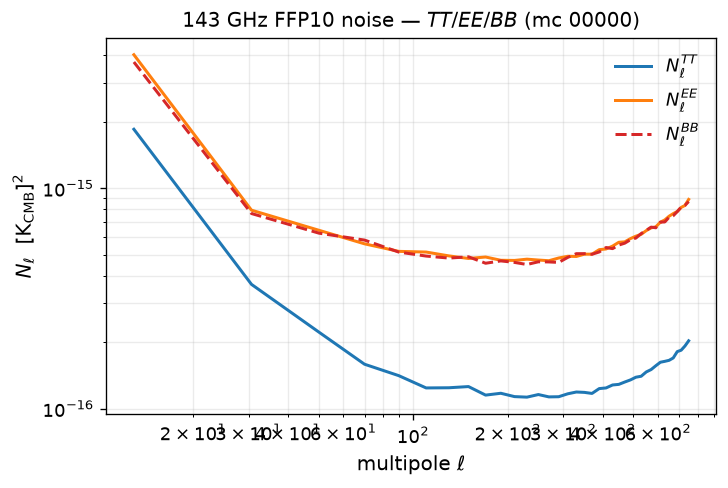

In [8]:
if is_polarized_channel(FOCUS_FREQ):
    print(f"Polarized spectra for {FOCUS_FREQ} GHz mc 00000 ...")
    iqu = load_noise_map(FOCUS_FREQ, 0, field=None, nside_out=nside_spec)
    pol = compute_pol_cls(iqu)

    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    for key, color, ls in [("TT", "C0", "-"), ("EE", "C1", "-"), ("BB", "C3", "--")]:
        ell_b, cl_b = bin_cl(pol[key])
        ax.loglog(ell_b, cl_b, color=color, ls=ls, lw=1.8, label=rf"$N_\ell^{{{key}}}$")
    ax.set_xlabel(r"multipole $\ell$")
    ax.set_ylabel(rf"$N_\ell$  [{map_units(FOCUS_FREQ)}$]^2$")
    ax.set_title(rf"{FOCUS_FREQ} GHz FFP10 noise — $TT/EE/BB$ (mc 00000)")
    ax.legend(frameon=False)
    ax.grid(True, which="both", alpha=0.25)
    fig.tight_layout()
    out = FIG_DIR / f"planck_noise_{FOCUS_FREQ}ghz_TT_EE_BB.png"
    fig.savefig(out, bbox_inches="tight")
    print("Saved", out)
    plt.show()
else:
    print(f"{FOCUS_FREQ} GHz is intensity-only — skipping EE/BB.")


## 6. Multi-frequency $N_\ell^{TT}$ overview

We compute temperature noise spectra for every frequency (realization 0) and overplot them.
Because 545/857 GHz use $\mathrm{MJy\,sr^{-1}}$ while lower HFI channels use
$\mathrm{K}_\mathrm{CMB}$, we **split the figure into two panels** rather than forcing a
spurious unit conversion.


N_ell TT: 100 GHz ...


N_ell TT: 143 GHz ...


N_ell TT: 217 GHz ...


N_ell TT: 353 GHz ...


N_ell TT: 545 GHz ...


N_ell TT: 857 GHz ...


Saved /home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures/planck_noise_Nell_TT_allfreq.png


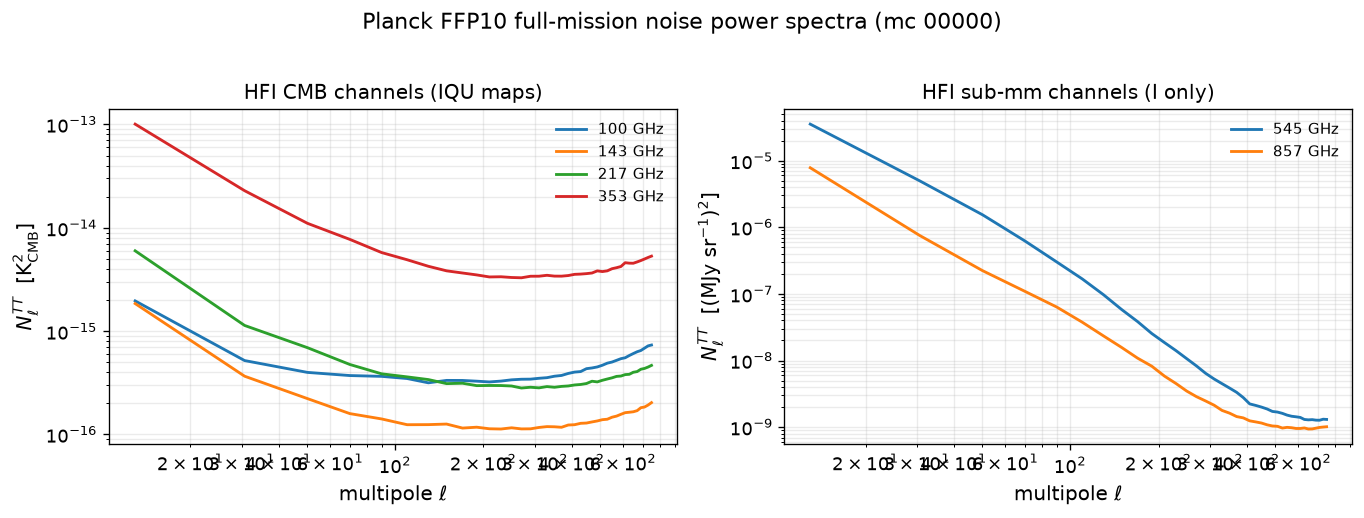

In [9]:
cls_tt: dict[int, np.ndarray] = {}
for freq in FREQS_ALL:
    print(f"N_ell TT: {freq} GHz ...")
    m = load_noise_map(freq, realization=0, field=0, nside_out=nside_spec)
    cls_tt[freq] = compute_cl(m)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Panel 1: K_CMB channels
ax = axes[0]
for freq in FREQS_POL:
    ell_b, cl_b = bin_cl(cls_tt[freq])
    ax.loglog(ell_b, cl_b, lw=1.7, label=rf"{freq} GHz")
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(r"$N_\ell^{TT}$  [K$_\mathrm{CMB}^2$]")
ax.set_title("HFI CMB channels (IQU maps)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", alpha=0.25)

# Panel 2: sub-mm intensity
ax = axes[1]
for freq in FREQS_INT:
    ell_b, cl_b = bin_cl(cls_tt[freq])
    ax.loglog(ell_b, cl_b, lw=1.7, label=rf"{freq} GHz")
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(r"$N_\ell^{TT}$  [(MJy sr$^{-1}$)$^2$]")
ax.set_title("HFI sub-mm channels (I only)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", alpha=0.25)

fig.suptitle(r"Planck FFP10 full-mission noise power spectra (mc 00000)", y=1.02)
fig.tight_layout()
out = FIG_DIR / "planck_noise_Nell_TT_allfreq.png"
fig.savefig(out, bbox_inches="tight")
print("Saved", out)
plt.show()


## 7. Optional: $D_\ell$ presentation and effective white-noise level

It is often convenient to quote a **white-noise equivalent** depth. For a spectrum that is
roughly flat over $\ell\in[\ell_{\min},\ell_{\max}]$,

$$
\sigma_N^{2}
\approx
\big\langle N_\ell\big\rangle_{\ell_{\min}\ldots\ell_{\max}}.
$$

A related map-level figure of merit is the **pixel RMS** at the analysis $N_\mathrm{side}$,
which already appeared in the histograms. Below we also plot
$D_\ell = \ell(\ell+1)N_\ell/2\pi$ (rising $\propto \ell^2$ for white noise) for the focus channel.


Saved /home/ext_andyxlcnb_gmail_com/flamingo_mock_analysis/figures/planck_noise_143ghz_Dell_whitelevel.png


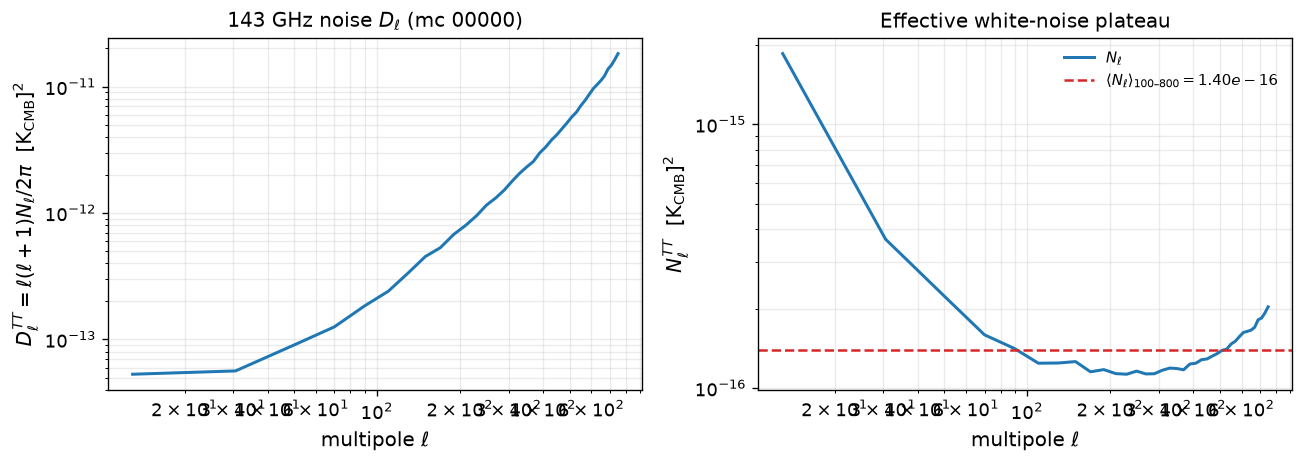

Focus channel 143 GHz:
  map RMS (analysis Nside=256): 2.5536e-06 K$_\mathrm{CMB}$
  <N_ell> over 100-800:                 1.3957e-16 [K$_\mathrm{CMB}$]^2


In [10]:
ell_b, cl_b = bin_cl(cl_00)
dl_b = dl_from_cl(ell_b, cl_b)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

ax = axes[0]
ax.loglog(ell_b, dl_b, lw=1.8, color="C0")
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(
    rf"$D_\ell^{{TT}}=\ell(\ell+1)N_\ell/2\pi$  [{map_units(FOCUS_FREQ)}$]^2$"
)
ax.set_title(rf"{FOCUS_FREQ} GHz noise $D_\ell$ (mc 00000)")
ax.grid(True, which="both", alpha=0.25)

# Effective white-noise level from mid-ell average of N_ell
ell_full = np.arange(cl_00.size)
mid = (ell_full >= 100) & (ell_full <= min(800, ell_full[-1]))
n_white = cl_00[mid].mean()
ax = axes[1]
ell_b2, cl_b2 = bin_cl(cl_00)
ax.loglog(ell_b2, cl_b2, lw=1.8, label=r"$N_\ell$")
ax.axhline(
    n_white, color="C3", ls="--", lw=1.5,
    label=rf"$\langle N_\ell\rangle_{{100\text{{–}}800}}={n_white:.2e}$",
)
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(rf"$N_\ell^{{TT}}$  [{map_units(FOCUS_FREQ)}$]^2$")
ax.set_title("Effective white-noise plateau")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()
out = FIG_DIR / f"planck_noise_{FOCUS_FREQ}ghz_Dell_whitelevel.png"
fig.savefig(out, bbox_inches="tight")
print("Saved", out)
plt.show()

print(f"Focus channel {FOCUS_FREQ} GHz:")
print(f"  map RMS (analysis Nside={nside_spec}): {I0.std():.4e} {map_units(FOCUS_FREQ)}")
print(f"  <N_ell> over 100-800:                 {n_white:.4e} [{map_units(FOCUS_FREQ)}]^2")


## 8. How to use these noise maps with FLAMINGO mocks

Typical coadd at frequency $\nu$:

$$
T_\nu^{\mathrm{obs}}
=
T_\nu^{\mathrm{CMB+tSZ+CIB+\ldots}}
+
n_\nu^{(r)},
$$

where $n_\nu^{(r)}$ is FFP10 realization $r$. Practical tips:

1. **Match units** before coadding. Mock CMB/tSZ are usually in $\mu\mathrm{K}_\mathrm{CMB}$;
   FFP10 100–353 GHz maps are in $\mathrm{K}_\mathrm{CMB}$ → multiply noise by $10^6$ for
   $\mu\mathrm{K}$. Sub-mm CIB mocks in $\mathrm{MJy\,sr^{-1}}$ match 545/857 GHz noise units
   directly.
2. **Match resolution / beam**. FFP10 maps are at $N_\mathrm{side}=2048$ and already include
   the effective noise after map-making (not a simple white field smoothed by the optical beam
   alone). If your signal maps are at $N_\mathrm{side}=4096$, either upgrade the noise with
   `ud_grade` (does not invent true small-scale noise power) or downgrade the signal.
3. **Independent realizations** (`mc_00000`, `mc_00001`, …) are useful for:
   - noise-bias subtraction via half-differences,
   - estimating the covariance of a pipeline (ILC, needlets, …),
   - null tests (`cross` of two noise-only maps $\approx 0$).
4. For half-mission noise splits (signal–noise separation à la Planck), download `hm1`/`hm2`
   products from PLA by changing `SPLIT` and the filenames.

### PLA download pattern

```text
https://pla.esac.esa.int/pla/aio/product-action?SIMULATED_MAP.FILE_ID=ffp10_noise_{freq}_{split}_map_mc_{XXXXX}.fits
```

## Notes & caveats

1. **Downgrading** (`USE_DOWNGRADE=True`) suppresses high-$\ell$ noise power and is only for
   interactive exploration. For quantitative $N_\ell$ set `USE_DOWNGRADE=False` and increase
   `LMAX_SPEC` (e.g. $3N_\mathrm{side}-1 = 6143$ at native resolution — slow / memory heavy).
2. Spectra here are **full-sky, unmasked**. Planck analyses usually apply a Galactic mask;
   masking couples modes and requires a mode-coupling (`MASTER` / `NaMaster`) correction.
3. Pixel-window deconvolution is applied; **beam deconvolution is not** — FFP10 noise maps
   are already map-level products (effective beam built into the noise realization).
4. 545/857 GHz units are $\mathrm{MJy\,sr^{-1}}$, not $\mathrm{K}_\mathrm{CMB}$. Convert with
   the Planck unit-conversion coefficients if you need thermodynamic units.

## References

1. Planck Collaboration (2020), *Planck 2018 results. I. Overview*, A&A 641, A1.
2. Planck Collaboration (2016), *Planck 2015 results. XII. Full Focal Plane simulations*,
   A&A 594, A12 — FFP description.
3. Planck Legacy Archive: [https://pla.esac.esa.int/](https://pla.esac.esa.int/)
